In [1]:
import juliet
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
import tqdm

In [25]:
# Open pickle file (which are the outputs of transitspectroscopy)
with open('/home/peng/Downloads/_nrs1_v1jw03385001001_toi1130_nrs1_spectrum.pkl', 'rb') as f:
    data = pickle.load(f)

# data is a dict with 7 entries: 
# 1. metadata: Information about instrument and detector, ex. name: NIRSpec, detector: NRS1
# 2. & 3. tso & tso_err: Not sure, just a bunch of zeroes as far as I can see
# 4. traces: Contains times in random order, x, ycorrected, ysmoothed
# 5 spectra: Contains times in increasing order, original + original_err, corrected + corrected_err, wavelength map (a bunch of nans) and wavelengths that the detector measures
# 6 & 7. whitelight & whitelight_err: Relative flux for white light curve and its errorbars

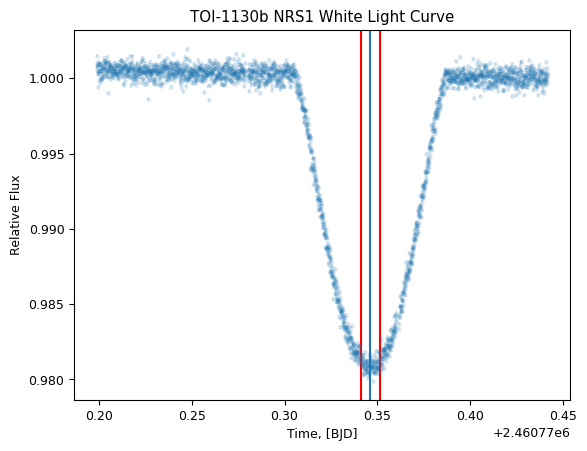

In [16]:
# Plot data points
t = data['spectra']['times']
f = data['whitelight']
ferr = data['whitelight_err']

plt.errorbar(t, f, yerr = ferr, fmt = '.', alpha = 0.1)
plt.title('TOI-1130b NRS1 White Light Curve')
plt.xlabel('Time, [BJD]')
plt.ylabel('Relative Flux')
plt.axvline(x = 2460770.3462201916)   # t[1550], I just eyeballed it
plt.axvline(x = 2460770.3462201916 + 0.005, color = 'r')
plt.axvline(x = 2460770.3462201916 - 0.005, color = 'r')
plt.show()

In [60]:
# Put into dictionaries
times, fluxes, fluxes_err =  {}, {}, {}
times['NRS1'], fluxes['NRS1'], fluxes_err['NRS1'] = t, f, ferr

# For WLC, Barat et al. paper fit quadratic ld params, semimajor axis, mid transit time and fixed everything else according to paper from Borsato et al, 2024
# For NRS1, need to also fit linear slope with theta0_JWST, add a param 'theta0_JWST' with a uniform prior, then in juliet.load, add linear_regressors_lc = ..., see juliet_fit_lc
priors = {}
params = ['P_p1', 't0_p1', 'r1_p1', 'r2_p1', 'q1_NRS1', 'q2_NRS1', 'ecc_p1', 'omega_p1', 'rho', 'mdilution_NRS1', 'mflux_NRS1','sigma_w_NRS1']
dists = ['fixed', 'uniform', 'uniform', 'uniform', 'uniform', 'uniform', 'fixed', 'fixed', 'loguniform', 'fixed', 'normal', 'loguniform']
hyperps = [4.074554, [2460770.3462201916-0.005, 2460770.3462201916+0.005], [0., 1.], [0., 1.], [0., 1.], [0., 1.], 
           0.052162, 141.111127, [1.97, 2.29], 1.0, [0., 0.1], [0.1, 1000.]]

for param, dist, hyperp in zip(params, dists, hyperps):
    priors[param] = {}
    priors[param]['distribution'], priors[param]['hyperparameters'] = dist, hyperp


# Load dataset
dataset = juliet.load(priors = priors, t_lc = times, y_lc = fluxes, yerr_lc = fluxes_err, out_folder = 'TOI-1130b_fit')
results = dataset.fit()

print('done')

PyMultinest installation not detected. Forcing dynesty as the sampler.


iter: 75900 | +500 | bound: 232 | nc: 1 | ncall: 2094215 | eff(%):  3.649 | loglstar:   -inf < -22093.548 <    inf | logz: -22244.622 +/-    nan | dlogz:  0.001 >  0.509                             

done


2460770.3412256464


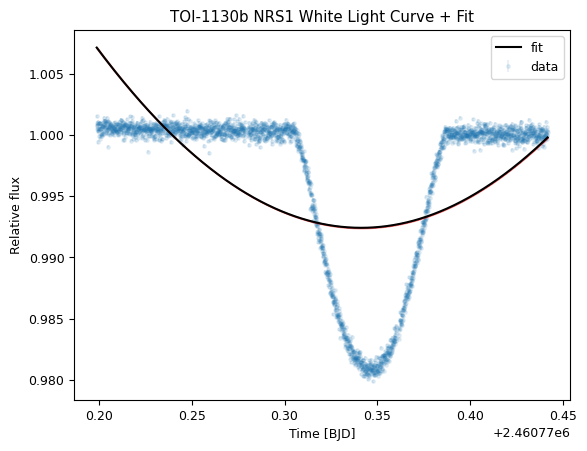

In [62]:
# From posterior, define best fit and +/- 1 sigma band
model, psigma, msigma = results.lc.evaluate('NRS1', return_err = True)

print(np.median((results.posteriors['posterior_samples']['t0_p1'])))

# Scatter data & plot
plt.errorbar(dataset.times_lc['NRS1'], dataset.data_lc['JWST'], yerr = dataset.errors_lc['JWST'], fmt='.', alpha = 0.1, label = 'data')

plt.plot(dataset.times_lc['JWST'], model, color = 'k', zorder = 10, label = 'fit') 
plt.fill_between(dataset.times_lc['JWST'], psigma, msigma, color = 'r', alpha = 0.5, zorder = 5)
plt.title('TOI-1130b NRS1 White Light Curve + Fit')
plt.xlabel('Time [BJD]')
plt.ylabel('Relative flux')

plt.legend()
plt.show()

[1.00695148 1.00693117 1.00691087 ... 1.00151978 1.00153606 1.00155235]
